<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/expno1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 IoE SENSOR DATA ACQUISITION AND PREPROCESSING

Original IoE Sensor Dataset:

   Light_Intensity  Soil_Moisture  CO2_Level  Wind_Speed  Rainfall
0              450             42        520          12         5
1              520             45        540          14         3
2              610             48        560          10         0
3              580             51        590          16         7
4              700             55        610          18         2
5              650             53        580          15         4
6              720             58        630          20         1
7              490             46        550          13         6
8              800             60        670          22         0
9              560             50        570          11         5

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------       

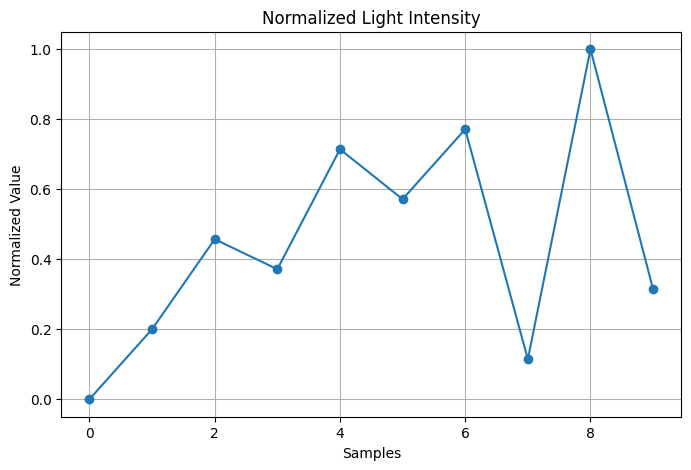

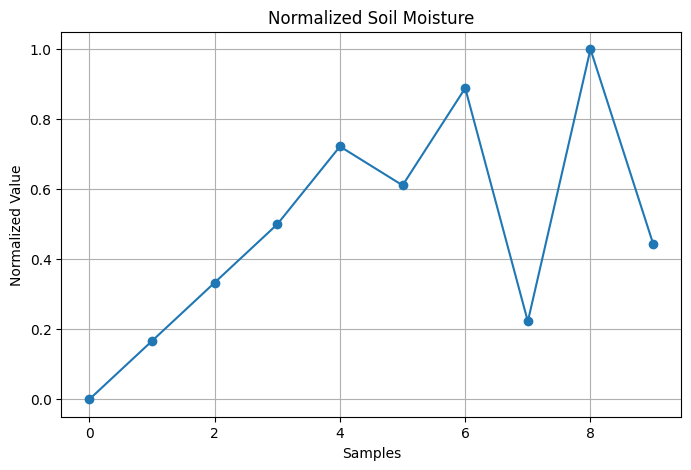

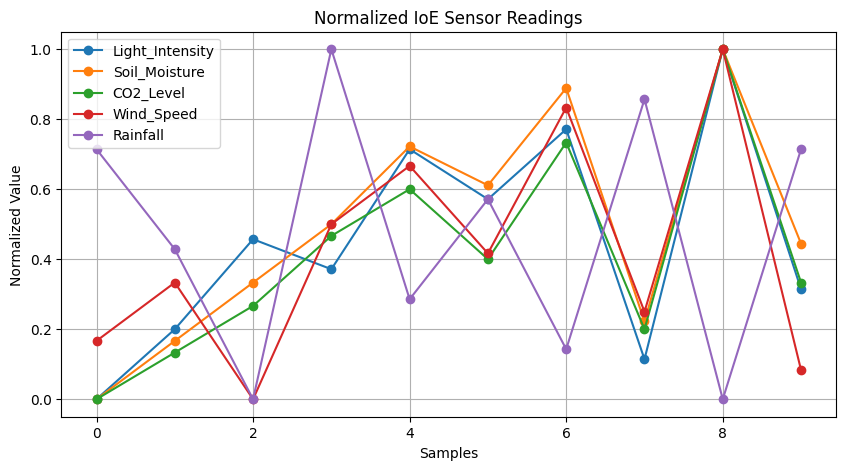

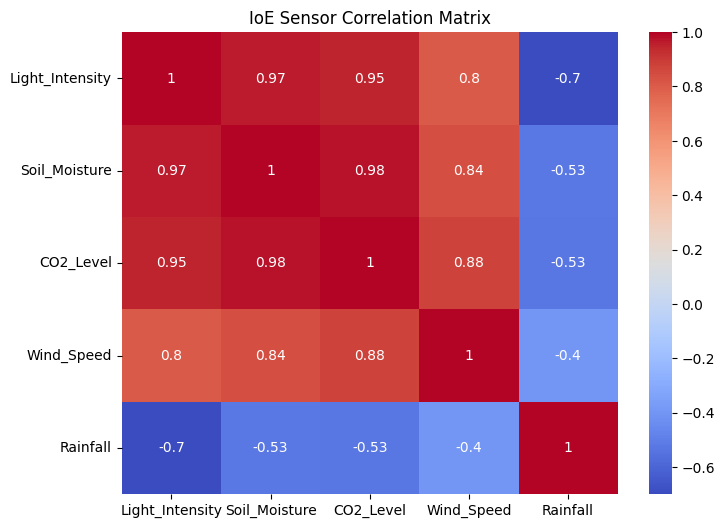


IoE DATA PREPROCESSING COMPLETED SUCCESSFULLY


In [1]:
# ============================================================
# EXPERIMENT - 1
# IoE Sensor Data Acquisition and Preprocessing
# Google Colab
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print(" IoE SENSOR DATA ACQUISITION AND PREPROCESSING")
print("=" * 60)

# ------------------------------------------------------------
# Create IoE Sensor Dataset
# ------------------------------------------------------------

data = {
    "Light_Intensity": [
        450, 520, 610, 580, 700,
        650, 720, 490, 800, 560
    ],

    "Soil_Moisture": [
        42, 45, 48, 51, 55,
        53, 58, 46, 60, 50
    ],

    "CO2_Level": [
        520, 540, 560, 590, 610,
        580, 630, 550, 670, 570
    ],

    "Wind_Speed": [
        12, 14, 10, 16, 18,
        15, 20, 13, 22, 11
    ],

    "Rainfall": [
        5, 3, 0, 7, 2,
        4, 1, 6, 0, 5
    ]
}

df = pd.DataFrame(data)

# ------------------------------------------------------------
# Display Original Dataset
# ------------------------------------------------------------

print("\nOriginal IoE Sensor Dataset:\n")
print(df)

# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

# ------------------------------------------------------------
# Check Missing Values
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# Fill Missing Values
# ------------------------------------------------------------

df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

# ------------------------------------------------------------
# Remove Duplicate Records
# ------------------------------------------------------------

before = len(df)

df.drop_duplicates(
    inplace=True
)

after = len(df)

print("\nDuplicate Records Removed:", before - after)

# ------------------------------------------------------------
# Outlier Detection using IQR
# ------------------------------------------------------------

print("\nOutlier Detection:")

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(
        column,
        "-> Outliers:",
        len(outliers)
    )

# ------------------------------------------------------------
# Normalize Sensor Data
# ------------------------------------------------------------

scaler = MinMaxScaler()

df[numeric_columns] = scaler.fit_transform(
    df[numeric_columns]
)

print("\nNormalized Dataset:\n")
print(df)

# ------------------------------------------------------------
# Save Clean Dataset
# ------------------------------------------------------------

df.to_csv(
    "clean_IoE_sensor_data.csv",
    index=False
)

print(
    "\nCleaned dataset saved as "
    "clean_IoE_sensor_data.csv"
)

# ------------------------------------------------------------
# Graph 1 - Light Intensity
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    df["Light_Intensity"],
    marker="o"
)

plt.title("Normalized Light Intensity")
plt.xlabel("Samples")
plt.ylabel("Normalized Value")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Graph 2 - Soil Moisture
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    df["Soil_Moisture"],
    marker="o"
)

plt.title("Normalized Soil Moisture")
plt.xlabel("Samples")
plt.ylabel("Normalized Value")
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Graph 3 - Sensor Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for column in numeric_columns:
    plt.plot(
        df[column],
        marker="o",
        label=column
    )

plt.title("Normalized IoE Sensor Readings")
plt.xlabel("Samples")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("IoE Sensor Correlation Matrix")

plt.show()

# ------------------------------------------------------------
# Final Message
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IoE DATA PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 60)